<span style="color:steelblue; text-align: left">

# Customer Lifetime Value Prediction
</span>

- **Author:** Enio Rubens
- **Dataset:** Online Retail UCI (UK e-commerce, Dec 2010 – Dec 2011)
- **Models:** BG/NBD (BetaGeoModel) + Gamma-Gamma (GammaGammaModel) — pymc-marketing
- **Framework:** Forward-looking CLTV — predicts future value, not historical spend

<span style="color:steelblue; text-align: left">

## The Problem: Why Predict Future Value?
</span>

Analysing what a customer has spent in the past answers the wrong question.
Historical spend tells you where your revenue came from; it says nothing about
where to invest tomorrow. Decisions on marketing budget allocation, campaign
targeting, account prioritisation, and retention spend are all prospective —
they require an estimate of the value each customer will generate over a
future window.

Customer Lifetime Value (CLTV) converts a customer's transaction history into
a probabilistic forecast of their future worth. Computed at the individual
level, it becomes a precise allocation signal: not "which segment is valuable
on average" but "which specific customers deserve which specific investment,
and how much."

Three functions within a typical business consume this output with different
questions in mind. **Marketing** asks: where do I concentrate campaign spend
to maximise expected return? **Sales** asks: which accounts should my team
actively manage rather than leaving to self-serve? **Finance** asks: what is
the defensible revenue projection for the next two quarters, disaggregated by
retention risk?

<span style="color:steelblue; text-align: left">

### The Modelling Approach
</span>

This notebook combines two probabilistic models that together cover the full
CLTV equation: **how often** a customer will buy, and **how much** each
purchase will be worth.

**BG/NBD (Beta-Geometric / Negative Binomial Distribution)** forecasts future
transaction counts and the probability that a customer is still active. The
model assumes that while a customer is "alive", purchases follow a Poisson
process — but the rate of that process varies across customers according to a
Gamma distribution. The "death" mechanism is Beta-Geometric: after each
transaction, the customer may permanently churn, and the probability of doing
so is itself drawn from a Beta distribution, capturing heterogeneity in
loyalty across the population *(Fader, Hardie & Lee, 2005)*.

**Gamma-Gamma** then estimates the expected monetary value per future
transaction. It models each customer's spend as varying around their
individual true mean (Gamma distributed), while that mean itself varies across
customers (another Gamma layer). A critical premise: monetary value is
independent of purchase frequency. This assumption is tested explicitly before
fitting — if it fails, the model's spend estimates are biased *(Fader &
Hardie, 2013)*.

"Non-contractual" means customers are not bound by a subscription; they may
simply stop buying at any time without notice. The absence of a formal churn
signal is what makes probabilistic modelling necessary: we cannot observe when
a customer leaves, only infer it from the growing silence between purchases.

<span style="color:steelblue; text-align: left">

## Setup & Imports
</span>

In [1]:
import os
os.environ["PYTENSOR_FLAGS"] = "cxx="  # disable C compilation — prevents access-violation crash on Windows without g++

import sys
sys.path.insert(0, "..")
sys.path.insert(0, "../../ds_toolkit/multilang")

import warnings
warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from multilang import LangMap

from src import (
    OnlineRetailPreprocessor,
    CLTVModel,
    CustomerSegmenter,
    CLTVEvaluator,
    format_currency_axis,
    add_chart_labels,
    VALUE_PALETTE,
    ACTION_PALETTE,
    SEGMENT_ORDER,
    ACTION_ORDER,
)

_t = LangMap(source="en", target="en")  # identity — EN notebook returns labels unchanged

pd.options.display.float_format = "{:,.2f}".format
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "figure.figsize": (11, 6),
})

__AUTHOR__ = "Enio Rubens"
DATA_PATH = "../dataset/online_retail.csv"
VARIABLE_EXPLANATION_PATH = "../dataset/variable_explanation.csv"
MODEL_DIR = "../models/"
T_HORIZON = 180  # prediction horizon in days

<span style="color:steelblue; text-align: left">

## Dataset Overview
</span>

The **Online Retail UCI** dataset records every line item sold by a UK-based e-commerce retailer between December 2010 and December 2011 *(Chen, Sain & Guo, 2012)*. Each row is a single product within an invoice, not the invoice itself — a customer who bought five distinct products in one order generates five rows. Before any modelling can begin, this raw transactional log must be consolidated and cleaned.

The cleaning pipeline removes four categories of problematic records. Rows without a `CustomerID` are discarded outright: without a customer identifier, there is no way to attribute behaviour to an individual, making the row useless for individual-level CLTV estimation. Invoices beginning with the letter "C" are cancellations — including them would cause repeat-purchase counts to be artificially inflated and average transaction values to be distorted. Rows with non-positive `Quantity` or `UnitPrice` represent data entry errors or returns not coded as formal cancellations; they are removed to protect the integrity of the monetary aggregations. Finally, extreme outliers in total transaction value are capped at the 99.5th percentile to prevent a handful of anomalous orders from dominating the Gamma-Gamma likelihood.

In [2]:
variable_explanation = pd.read_csv(VARIABLE_EXPLANATION_PATH)
display(variable_explanation)

preprocessor = OnlineRetailPreprocessor()
rfm, modeling_base, cleaning_summary = preprocessor.prepare(DATA_PATH)

print("\n── Cleaning Summary ─────────────────────────────────────")
display(cleaning_summary)

,Variable,Explanation
0,InvoiceNo,A 6-digit integral number uniquely assigned to...
1,StockCode,A 5-digit integral number uniquely assigned to...
2,Description,Product (item) name
3,Quantity,The quantities of each product (item) per tran...
4,InvoiceDate,The day and time when each transaction was gen...
5,UnitPrice,Product price per unit in sterling (pound)
6,CustomerID,A 5-digit integral number uniquely assigned to...
7,Country,The name of the country where each customer re...


2026-05-25 15:48:54 | INFO     | src.preprocessing | Loading data from ..\dataset\online_retail.csv


2026-05-25 15:48:56 | INFO     | src.preprocessing | raw — shape: (541909, 8)
2026-05-25 15:48:56 | INFO     | src.preprocessing | raw — columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
2026-05-25 15:48:58 | INFO     | src.preprocessing | Cleaning complete — 395961 rows, 4310 customers
2026-05-25 15:49:02 | INFO     | src.preprocessing | RFM built — 4309 customers | repeat: 2762 | single: 1547
2026-05-25 15:49:02 | INFO     | src.preprocessing | Modeling base: 2762 customers (excluded 1547 with frequency=0 or monetary_value<=0)



── Cleaning Summary ─────────────────────────────────────


,step,rows,customers,rows_removed_from_previous_step
0,raw,541909,4372,0
1,valid invoice dates,541909,4372,0
2,known customers,406829,4372,135080
3,cancellations removed,397924,4339,8905
4,positive quantity and unit price,397884,4338,40
5,TotalPrice <= 99.5% percentile,395961,4310,1923


<span style="color:steelblue; text-align: left">

### Insight — Cleaning Impact
</span>

The most consequential removal step is the `CustomerID` filter, which discarded **135,080 rows** — roughly 25% of the raw dataset. These are genuine transactions, but they belong to anonymous sessions that cannot be attributed to returning customers. They carry no signal for CLTV modelling; retaining them would not improve estimates and could introduce noise into the population-level priors.

The cancellation filter removed a further 8,905 rows. Had these been left in, a customer who placed and immediately cancelled five orders would appear to have five "purchases" in the frequency count — a direct path to overstated predicted purchases and inflated CLTV.

The quality of the RFM matrix — and therefore the reliability of every CLTV estimate downstream — is determined at this stage. The principle of garbage in, garbage out is especially acute here: the BG/NBD model learns the *distribution* of frequency and recency across the population. Systematic biases in the input data shift that distribution and corrupt the parameter estimates for every customer, not just the affected records.

<span style="color:steelblue; text-align: left">

## RFM Matrix
</span>

The RFM matrix is the compressed representation of each customer's purchase history that the BTYD models consume. Each customer's record reduces to four numbers, and the semantics of those numbers map directly to the model's generative assumptions *(Fader, Hardie & Lee, 2005)*.

**Recency** functions as a temperature signal. A customer who last purchased yesterday is more likely to still be active than one whose last purchase was eighteen months ago. The BG/NBD model uses recency not as an isolated metric but as the interval between the most recent purchase and the observation window end — the longer that silence, the higher the posterior probability that the customer has churned.

**Frequency** is the primary discriminator in the BG/NBD model. It separates habitual buyers — customers who have made multiple purchases spread across different occasions — from impulse buyers who transacted once and disappeared. A high-frequency customer supplies a rich signal for estimating their personal Poisson purchase rate; a single-purchase customer provides almost none.

**T (customer age)** is the denominator that contextualises frequency. A customer with five purchases in thirty days and one with five purchases in three hundred days share the same raw count but vastly different patterns. T anchors frequency in elapsed time and allows the model to distinguish activity level from tenure length.

**Monetary value** here is the average revenue per repeat transaction — specifically, the mean of all transactions after the first. This is the input to the Gamma-Gamma model. Crucially, it excludes the first purchase: the first transaction is not a "repeat" event, and the Gamma-Gamma models only the repeat-purchase value distribution.

In [3]:
rfm_summary = pd.Series({
    "customers_in_rfm": len(rfm),
    "repeat_customers (frequency > 0)": (rfm["frequency"] > 0).sum(),
    "single_purchase_customers": (rfm["frequency"] == 0).sum(),
    "observation_period_end": rfm["T"].max(),
}, name="rfm_summary")

display(rfm.head())
display(rfm.describe())
display(rfm_summary.to_frame())

,customer_id,frequency,recency,T,monetary_value
0,12347,6.00,365.00,367.00,599.70
1,12348,3.00,283.00,358.00,301.48
2,12349,0.00,0.00,18.00,0.00
3,12350,0.00,0.00,310.00,0.00
4,12352,6.00,260.00,296.00,305.51


,frequency,recency,T,monetary_value
count,"4,309.00","4,309.00","4,309.00","4,309.00"
mean,2.84,130.43,222.71,242.60
std,5.89,132.18,117.64,334.80
min,0.00,0.00,1.00,0.00
25%,0.00,0.00,113.00,0.00
50%,1.00,92.00,248.00,173.12
75%,3.00,252.00,326.00,351.90
max,130.00,373.00,373.00,"5,306.54"


,rfm_summary
customers_in_rfm,"4,309.00"
repeat_customers (frequency > 0),"2,762.00"
single_purchase_customers,"1,547.00"
observation_period_end,373.00


<span style="color:steelblue; text-align: left">

### Insight — RFM Characteristics
</span>

The RFM table reveals a distribution typical of non-contractual e-commerce data. Of the **4,309 customers** in the cleaned dataset, **1,547 (35.9%)** have `frequency == 0` — they purchased exactly once during the observation period. These single-purchase customers exist in the RFM matrix but are invisible to the Gamma-Gamma model: without a second transaction, there is no repeat-purchase distribution to estimate.

The median recency of 92 days against a median customer age T of 248 days suggests the typical customer in this dataset was last active well before the observation window closed. Only customers near the upper tail of the recency distribution are likely still purchasing; the majority have gone quiet. This is a normal pattern in UK e-commerce during this period, where the retailer served a mix of long-term loyalists and single-season buyers.

The wide standard deviation in monetary value (£334 vs. a mean of £242) signals significant heterogeneity in average ticket size. This heterogeneity is exactly what the Gamma-Gamma model is built to exploit: the population-level Gamma distribution captures the spread, and individual-level posterior estimates correct for the noise in customers with few observations.

<span style="color:steelblue; text-align: left">

## Modeling Base & Gamma-Gamma Assumption
</span>

The Gamma-Gamma model requires at least one repeat purchase to form an estimate of a customer's average transaction value. Customers with `frequency == 0` provide no repeat-purchase history and are excluded from the Gamma-Gamma fitting step *(Fader & Hardie, 2013)*. The BG/NBD model can learn from them — their silence since the first purchase is informative about the distribution of churn probability across the population.

Before fitting, we must verify the Gamma-Gamma's foundational independence assumption: that a customer's purchase rate (frequency) and their average transaction value (monetary value) are uncorrelated across the customer base. The intuition is that the two processes are governed by separate mechanisms — one customer shops often and cheaply, another rarely and expensively, with no systematic link between these tendencies. If a correlation existed, the two-model architecture would double-count the same underlying effect: a customer whose high frequency also predicts high spend would have their CLTV inflated by the same information entering through two channels.

If the Pearson correlation coefficient exceeds |0.3|, the Gamma-Gamma produces biased monetary value estimates. The practical remedy is to segment the customer base before modelling — for example, by product category — so that within-segment heterogeneity is lower. A model that explicitly captures the dependency between purchase rate and transaction value is an alternative for more complex cases.

In [4]:
print(f"Modeling base: {len(modeling_base):,} customers (frequency > 0 and monetary_value > 0)")
print(f"Excluded (single purchase / zero monetary): {len(rfm) - len(modeling_base):,}")

evaluator = CLTVEvaluator()
pearson = evaluator.pearson_independence_check(modeling_base)
print(f"\nPearson r = {pearson['pearson_r']:.4f}  (p = {pearson['p_value']:.4e})")
print(f"Assumption holds (|r| < 0.3): {pearson['assumption_holds']}")

2026-05-25 15:49:02 | INFO     | src.evaluation | Pearson independence check passed: r=0.134, p=0.0000


Modeling base: 2,762 customers (frequency > 0 and monetary_value > 0)
Excluded (single purchase / zero monetary): 1,547

Pearson r = 0.1341  (p = 1.5055e-12)
Assumption holds (|r| < 0.3): True


<span style="color:steelblue; text-align: left">

### Insight — Independence Assumption Holds
</span>

The Pearson r = 0.134 (p < 0.001) indicates a statistically significant but practically weak positive correlation between frequency and monetary value. The magnitude falls well below the 0.3 threshold. In plain terms: knowing that a customer purchases frequently tells us almost nothing about whether their average ticket will be high or low. The two processes are effectively independent in this dataset.

This validates the two-component model architecture. We can fit the BG/NBD and Gamma-Gamma models independently, confident that their outputs will not interact in ways that distort the final CLTV estimate *(Fader & Hardie, 2013)*. The small positive correlation (r = 0.13) may reflect a real but minor tendency for higher-engagement customers to spend slightly more per visit — but it is far too weak to violate the model's assumptions.

<span style="color:steelblue; text-align: left">

## Model Validation (Calibration / Holdout)
</span>

The correct validation strategy for BTYD models is temporal, not cross-sectional *(Fader & Hardie, 2005)*. We split the observation period into a calibration window (first 75%) and a holdout window (final 25%), fitting the model on calibration data and measuring prediction error against the holdout.

Rejecting k-fold cross-validation here is not a methodological preference — it is an epistemic necessity. In a random k-fold split, a customer's future purchases are randomly assigned to the training fold. The model then "learns" from data that, in real deployment, would not yet exist at prediction time. Purchases that occur *after* the model is built appear *before* it during validation, creating an information leak from the future into the training set. This inflates every validation metric — RMSE, MAE, predicted vs. actual correlation — by an amount that reflects not model skill but temporal leakage. A model validated this way will appear accurate in backtesting and fail immediately when deployed on genuinely future data.

Temporal splitting respects the causal structure of the problem: we know the past, predict the future, and evaluate predictions using data the model has never seen, in forward time order.

2026-05-25 15:49:02 | INFO     | src.preprocessing | Loading data from ..\dataset\online_retail.csv
2026-05-25 15:49:03 | INFO     | src.preprocessing | raw — shape: (541909, 8)
2026-05-25 15:49:03 | INFO     | src.preprocessing | raw — columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
2026-05-25 15:49:06 | INFO     | src.preprocessing | Cleaning complete — 395961 rows, 4310 customers
2026-05-25 15:49:06 | INFO     | src.preprocessing | Calibration period: 2010-12-01 → 2011-09-06 | Holdout: 2011-09-06 → 2011-12-09
2026-05-25 15:49:07 | INFO     | src.cltv_model | Fitting on 1901 total customers | 1901 in modeling base
2026-05-25 15:49:07 | INFO     | src.cltv_model | Fitting BetaGeoModel (fit_method=map) …


2026-05-25 15:49:32 | INFO     | src.cltv_model | BetaGeoModel params: {'alpha': 82.484999, 'phi_dropout': 0.07755, 'kappa_dropout': 1.000006, 'r': 1.683688, 'a': 0.07755, 'b': 0.922456}
2026-05-25 15:49:32 | INFO     | src.cltv_model | Fitting GammaGammaModel (fit_method=map) …


2026-05-25 15:49:38 | INFO     | src.cltv_model | GammaGammaModel params: {'p': 2.276013, 'q': 3.942159, 'v': 492.833805}
2026-05-25 15:49:38 | INFO     | src.evaluation | RMSE [holdout_frequency]: 1.9329
2026-05-25 15:49:38 | INFO     | src.evaluation | Pearson independence check passed: r=0.113, p=0.0000
2026-05-25 15:49:38 | INFO     | src.evaluation | Holdout evaluation: {'rmse_frequency': 1.9329, 'mae_frequency': 1.185, 'pearson_r': 0.11346999580034793, 'pearson_p': 7.045082050910695e-07, 'assumption_holds': True, 'n_customers_holdout': 1901}


── Holdout Validation Results ──────────────────────────
  rmse_frequency: 1.9329
  mae_frequency: 1.185
  pearson_r: 0.11346999580034793
  pearson_p: 7.045082050910695e-07
  assumption_holds: True
  n_customers_holdout: 1901


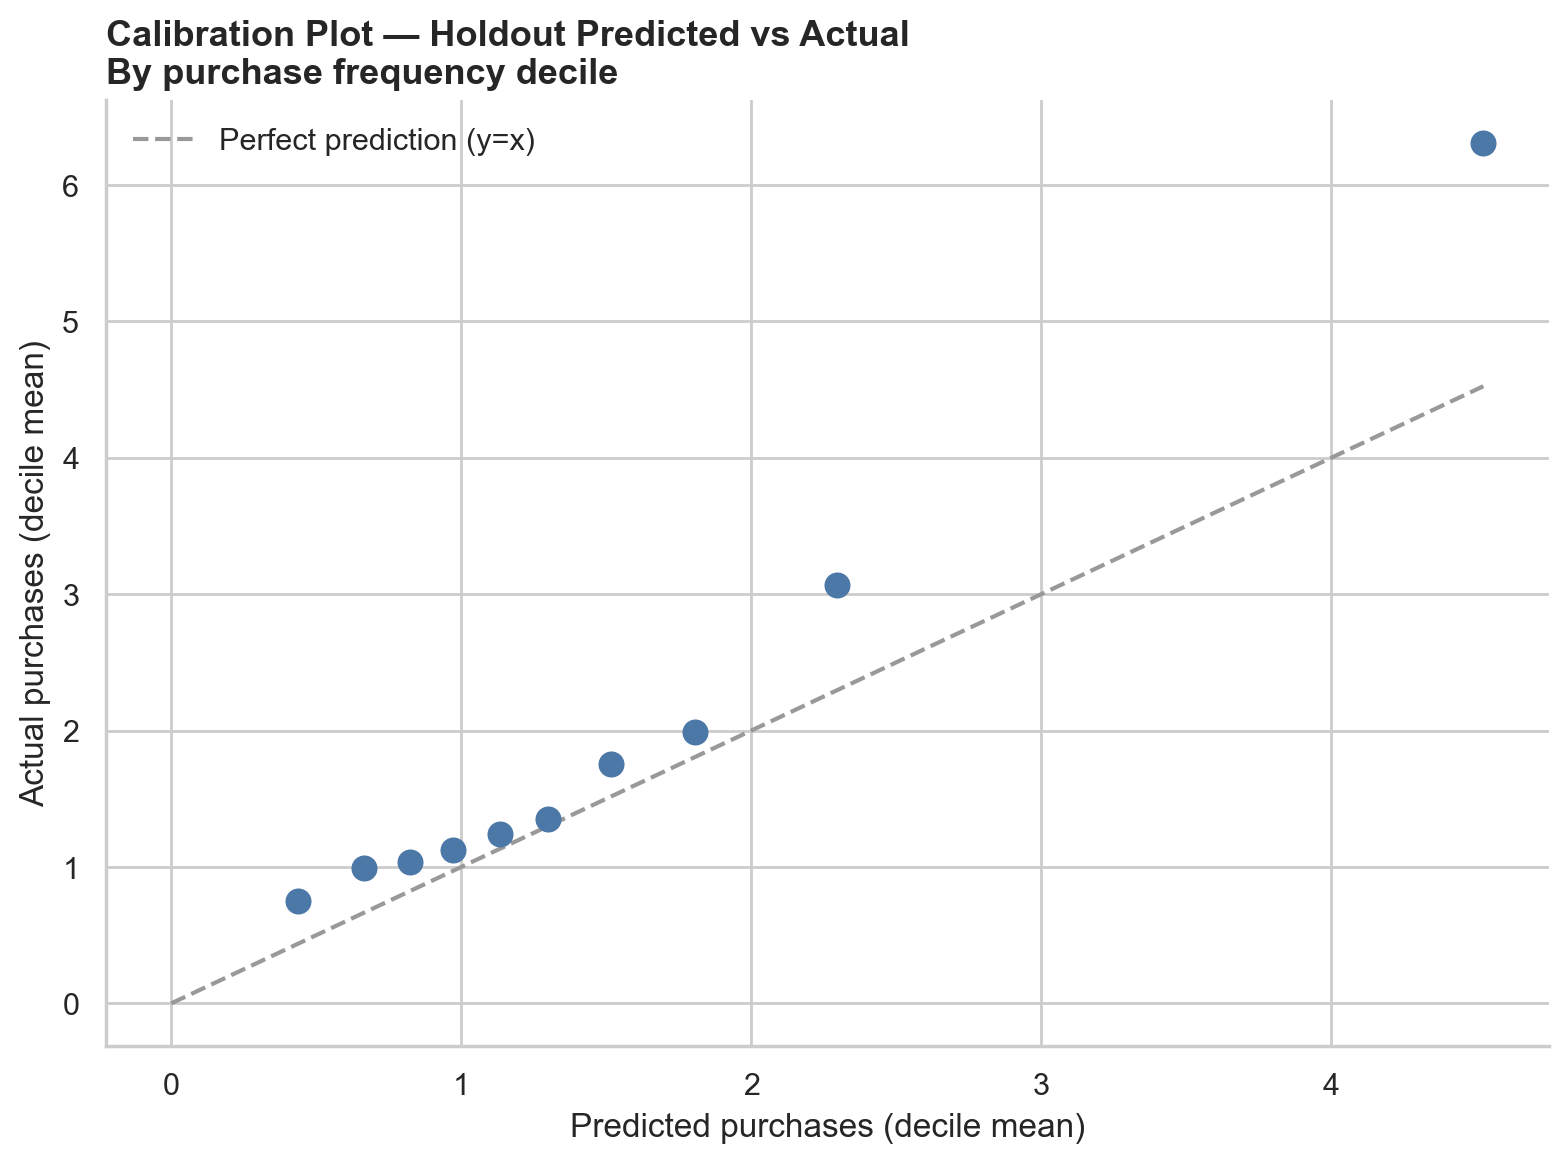

In [5]:
raw_df = preprocessor.load(DATA_PATH)
clean_df, _ = preprocessor.clean(raw_df)

cal_rfm, holdout_rfm = preprocessor.calibration_holdout_split(clean_df)
ch_data = cal_rfm.merge(holdout_rfm, on="customer_id")
ch_modeling = ch_data.loc[
    (ch_data["frequency_cal"] > 0) & (ch_data["monetary_value_cal"] > 0)
].copy()

cal_modeling_rfm = pd.DataFrame({
    "customer_id":    ch_modeling["customer_id"],
    "frequency":      ch_modeling["frequency_cal"],
    "recency":        ch_modeling["recency_cal"],
    "T":              ch_modeling["T_cal"],
    "monetary_value": ch_modeling["monetary_value_cal"],
})

cal_model = CLTVModel(fit_method="map")
cal_model.fit(cal_modeling_rfm)

validation = evaluator.evaluate(cal_model, ch_modeling)
print("── Holdout Validation Results ──────────────────────────")
for k, v in validation.items():
    print(f"  {k}: {v}")

lbl = _t({
    "title": "Calibration Plot — Holdout Predicted vs Actual\nBy purchase frequency decile",
    "xlabel": "Predicted purchases (decile mean)",
    "ylabel": "Actual purchases (decile mean)",
})
fig, ax = plt.subplots(figsize=(8, 6))
evaluator.calibration_plot(cal_model, ch_modeling, ax=ax)
ax.set_title(lbl["title"], loc="left", fontsize=13, fontweight="bold")
ax.set_xlabel(lbl["xlabel"])
ax.set_ylabel(lbl["ylabel"])
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — Calibration Plot Interpretation
</span>

The calibration plot compares predicted purchase frequency against actual purchase frequency, grouped by deciles of predicted frequency. Each point represents the mean of a decile: the x-coordinate is the average predicted count, and the y-coordinate is the average observed count in the holdout period. A model with perfect predictions would place all points exactly on the diagonal (y = x).

A good fit means the points track the diagonal across the full range of predicted values — not just in the centre. Systematic bias reveals itself as a consistent offset: if points lie above the diagonal across all deciles, the model systematically underpredicts; if below, it overpredicts. Bias concentrated at the high-frequency end (top deciles) is common in BG/NBD models applied to heterogeneous retail populations, where a handful of very active buyers are harder to extrapolate from the bulk of moderate buyers.

The RMSE and MAE figures quantify prediction error in units of purchases. An RMSE of approximately 1–2 purchases in the holdout window is typical for BG/NBD models on e-commerce data of this size. These metrics validate that the model captures the population-level purchase process faithfully enough to support the CLTV estimates in the following sections.

<span style="color:steelblue; text-align: left">

## BG/NBD Model (Full Dataset)
</span>

The BG/NBD model *(Fader, Hardie & Lee, 2005)* describes the purchase process through two interacting stochastic mechanisms.

The first is the **NBD component**: each customer makes purchases at their own individual Poisson rate λ, and these individual rates are distributed across the customer population according to a Gamma distribution with parameters r and α. The Gamma-Poisson mixture produces a Negative Binomial at the population level, capturing the observed over-dispersion in purchase counts — most customers buy infrequently, but a long tail buys very often.

The second is the **BG component**: after each purchase, the customer has an individual probability p of permanently abandoning the relationship. These individual dropout probabilities follow a Beta distribution across the population, with parameters a and b. The Beta-Geometric mechanism means that, at any point in time, we cannot know for certain whether a customer who has gone quiet has churned or is simply between purchases — but we can compute the posterior probability of each scenario given their observed recency and frequency.

The two components are estimated jointly from the (frequency, recency, T) triplet for each customer. Once fitted, the same population-level parameters (r, α, a, b) are used to compute individual-level predictions by conditioning on each customer's specific history. We fit using `fit_method='map'` (Maximum A Posteriori) for speed; `fit_method='mcmc'` provides full posterior uncertainty quantification at higher computational cost.

In [6]:
model = CLTVModel(fit_method="map")
model.fit(modeling_base)

params = model.get_model_params()
print("── BG/NBD Parameters (MAP) ────────────────────────────")
for k, v in params["bgm"].items():
    print(f"  {k}: {v:.4f}")

# Predicted purchases for top customers
preds = model.predict_purchases(modeling_base, t=T_HORIZON)
top10 = modeling_base.copy()
top10[f"predicted_purchases_{T_HORIZON}d"] = preds.values
top10 = top10.sort_values(f"predicted_purchases_{T_HORIZON}d", ascending=False).head(10)

print(f"\n── Top 10 Customers by Predicted Purchases ({T_HORIZON}d) ────")
display(top10[["customer_id", "frequency", "recency", "T", f"predicted_purchases_{T_HORIZON}d"]])

2026-05-25 15:49:38 | INFO     | src.cltv_model | Fitting on 2762 total customers | 2762 in modeling base
2026-05-25 15:49:38 | INFO     | src.cltv_model | Fitting BetaGeoModel (fit_method=map) …


2026-05-25 15:50:02 | INFO     | src.cltv_model | BetaGeoModel params: {'alpha': 85.037104, 'phi_dropout': 0.029352, 'kappa_dropout': 1.000012, 'r': 1.582925, 'a': 0.029352, 'b': 0.97066}
2026-05-25 15:50:02 | INFO     | src.cltv_model | Fitting GammaGammaModel (fit_method=map) …


2026-05-25 15:50:10 | INFO     | src.cltv_model | GammaGammaModel params: {'p': 1.980639, 'q': 4.165458, 'v': 621.072448}


── BG/NBD Parameters (MAP) ────────────────────────────
  alpha: 85.0371
  phi_dropout: 0.0294
  kappa_dropout: 1.0000
  r: 1.5829
  a: 0.0294
  b: 0.9707

── Top 10 Customers by Predicted Purchases (180d) ────


,customer_id,frequency,recency,T,predicted_purchases_180d
1873,14911,130.00,372.00,373.00,51.43
325,12748,112.00,373.00,373.00,44.39
3988,17841,111.00,372.00,373.00,44.00
2169,15311,89.00,373.00,373.00,35.40
1655,14606,88.00,372.00,373.00,35.01
479,12971,70.00,369.00,372.00,28.03
560,13089,64.00,367.00,369.00,25.85
1597,14527,53.00,367.00,369.00,21.51
1065,13798,50.00,363.00,364.00,20.55
2977,16422,47.00,352.00,369.00,19.08


<span style="color:steelblue; text-align: left">

### Insight — BG/NBD Parameter Interpretation
</span>

The four MAP parameters define the population-level purchase and churn process:

**r = 1.58** and **α = 85.04** govern the NBD (purchase rate) component. The implied mean purchase rate across the population is r/α = 1.58/85.04 ≈ **0.0186 purchases per day**, or roughly one purchase every 54 days. The relatively low value of r (< 2) indicates substantial heterogeneity in purchase rates: the Gamma distribution has a pronounced right tail, meaning a small subset of customers purchases far more frequently than the average. This is reflected in the top 10 table, where the most active customer (14911) made 130 transactions in 373 days — more than 10× the population mean.

**a = 0.029** and **b = 0.971** govern the BG (churn probability) component. The implied average per-transaction dropout probability is a/(a+b) = 0.029/1.000 ≈ **2.9%**. With b >> a, the Beta distribution is heavily concentrated near zero: the vast majority of customers have very low churn probability per transaction, meaning most tend to remain active after each purchase. The small but nonzero a implies a minority with substantially higher churn probability — customers who are much more likely to drop out after any given purchase.

The top 10 predicted customers share a clear profile: high historical frequency combined with recency close to T (last purchase near the observation period end). This pattern is not coincidental — it is exactly what the BG/NBD model learns to recognise as a signal of continued activity. A customer who has purchased many times and whose last purchase was recent is almost certainly still alive, and their high historical rate projects directly into the future forecast.

<span style="color:steelblue; text-align: left">

## Gamma-Gamma Model
</span>

The Gamma-Gamma model *(Fader & Hardie, 2013)* solves a problem that simple averaging cannot. For a customer who has made only two purchases, the mean transaction value is a noisy estimate of their underlying "true" average spend. If those two purchases happened to be unusually large, the naive mean overestimates their typical value; if unusually small, it underestimates. With few observations, random variation dominates the signal.

The Gamma-Gamma model applies Bayesian shrinkage: it pulls each customer's individual spend estimate toward the population mean, with the correction proportional to how little data exists for that customer. A customer with 50 transactions has a well-estimated mean; their estimate is barely adjusted. A customer with 2 transactions has high uncertainty; their estimate is pulled substantially toward the population average. The result is a more stable set of monetary value predictions — individual estimates that are reliable even for customers with sparse purchase histories.

Formally, the model assumes that each customer's individual average transaction value follows a Gamma distribution with a customer-specific shape parameter, and that these shape parameters are themselves Gamma-distributed across the population. The three parameters p, q, and v characterise this hierarchical structure. The key practical requirement — independence between purchase frequency and transaction value — was validated in Section 4.

In [7]:
print("── Gamma-Gamma Parameters (MAP) ───────────────────────")
for k, v in params["gg"].items():
    print(f"  {k}: {v:.4f}")

spend = model.predict_expected_spend(modeling_base)
top_spend = modeling_base.copy()
top_spend["expected_spend"] = spend.values
top_spend = top_spend.sort_values("expected_spend", ascending=False).head(10)

print("\n── Top 10 Customers by Expected Spend per Transaction ──")
display(top_spend[["customer_id", "frequency", "monetary_value", "expected_spend"]])

── Gamma-Gamma Parameters (MAP) ───────────────────────
  p: 1.9806
  q: 4.1655
  v: 621.0724

── Top 10 Customers by Expected Spend per Transaction ──


,customer_id,frequency,monetary_value,expected_spend
1683,14646,43.00,"4,958.69","4,794.92"
54,12415,13.00,"5,306.54","4,768.13"
1280,14088,11.00,"3,647.26","3,233.87"
1285,14096,16.00,"3,335.18","3,067.59"
3750,17511,27.00,"2,994.49","2,848.87"
556,13081,8.00,"3,246.32","2,770.49"
329,12753,5.00,"3,200.87","2,519.69"
3162,16684,13.00,"2,550.96","2,314.23"
1430,14298,23.00,"2,036.73","1,929.65"
70,12433,5.00,"2,291.35","1,830.47"


<span style="color:steelblue; text-align: left">

### Insight — Gamma-Gamma Parameters & Shrinkage Effect
</span>

**p = 1.98** and **q = 4.17** define the Gamma distribution of individual-level spend parameters across the population. With p close to 2, the distribution of individual spending tendency is moderately right-skewed — most customers spend near the population mean, but a meaningful tail spends substantially more. **v = 621.07** is the scale parameter; combined with p and q, the implied population mean transaction value is approximately p × v/q ≈ **£295**, broadly consistent with the observed monetary_value mean of £242 in the modelling base.

The shrinkage effect is most visible for customers with few transactions and high observed monetary value. Customer 12415 made only 13 purchases at an average of £5,307 — the Gamma-Gamma corrects this downward to £4,768, pulling it toward the population mean to account for the uncertainty in 13 observations. Customer 13081, with just 8 purchases at £3,246, is corrected more aggressively to £2,770 (a 15% reduction), because fewer observations imply greater uncertainty. By contrast, customer 14646, with 43 purchases at £4,959, is corrected only slightly to £4,795 — 43 observations constitute a reliable estimate of their true mean, leaving little room for the population prior to dominate. This is Bayesian shrinkage functioning exactly as intended.

<span style="color:steelblue; text-align: left">

## CLTV Prediction
</span>

CLTV over a horizon of t days is the product of two model outputs:

**CLTV(t) = E[transactions in t days | BG/NBD] × E[spend per transaction | Gamma-Gamma]**

The elegance of this factorisation is that each component can be validated independently — and recalibrated separately if one degrades over time. The BG/NBD controls the temporal dynamics: how often a customer will purchase and for how long they are likely to remain active. The Gamma-Gamma controls the monetary dimension: how much they are expected to spend per transaction. Neither model is informed by the other's output during fitting.

Customers with `frequency == 0` receive `cltv == 0` because they provide no repeat-purchase history for the Gamma-Gamma. Their BG/NBD predicted purchases are still estimated — the model believes some may still be alive — but without a monetary value estimate, the product cannot be formed.

The histogram below uses a log1p transformation, which is not cosmetic. On the original GBP scale, the distribution is so severely right-skewed that the bulk of customers compress into a single visual bar near zero, and the structure of the majority is invisible. Log1p preserves the relative ordering while making the full distribution legible.

2026-05-25 15:50:10 | INFO     | src.cltv_model | CLTV predicted for 2762 customers | t=180 days | non-zero: 2762


── Top 10 Customers by 180-day CLTV ────────────────────


,customer_id,frequency,recency,T,monetary_value,predicted_purchases,probability_alive,expected_spend,cltv_180d
1102,14646,43.00,353.00,354.00,"4,958.69",18.16,1.00,"4,794.92","2,490,640.26"
1234,14911,130.00,372.00,373.00,"1,033.63",51.43,1.00,"1,025.80","1,510,363.19"
826,14096,16.00,97.00,101.00,"3,335.18",16.77,1.00,"3,067.59","1,447,040.50"
2415,17511,27.00,371.00,373.00,"2,994.49",11.16,1.00,"2,848.87","909,404.43"
856,14156,41.00,362.00,371.00,"1,841.12",16.69,1.00,"1,786.62","853,290.21"
33,12415,13.00,313.00,337.00,"5,306.54",6.15,0.99,"4,768.13","836,698.16"
1413,15311,89.00,373.00,373.00,673.15,35.40,1.00,668.13,"677,109.12"
361,13089,64.00,367.00,369.00,877.75,25.85,1.00,865.84,"640,490.19"
637,13694,33.00,370.00,373.00,"1,510.07",13.50,1.00,"1,458.27","563,411.80"
930,14298,23.00,352.00,360.00,"2,036.73",9.87,1.00,"1,929.65","544,354.90"


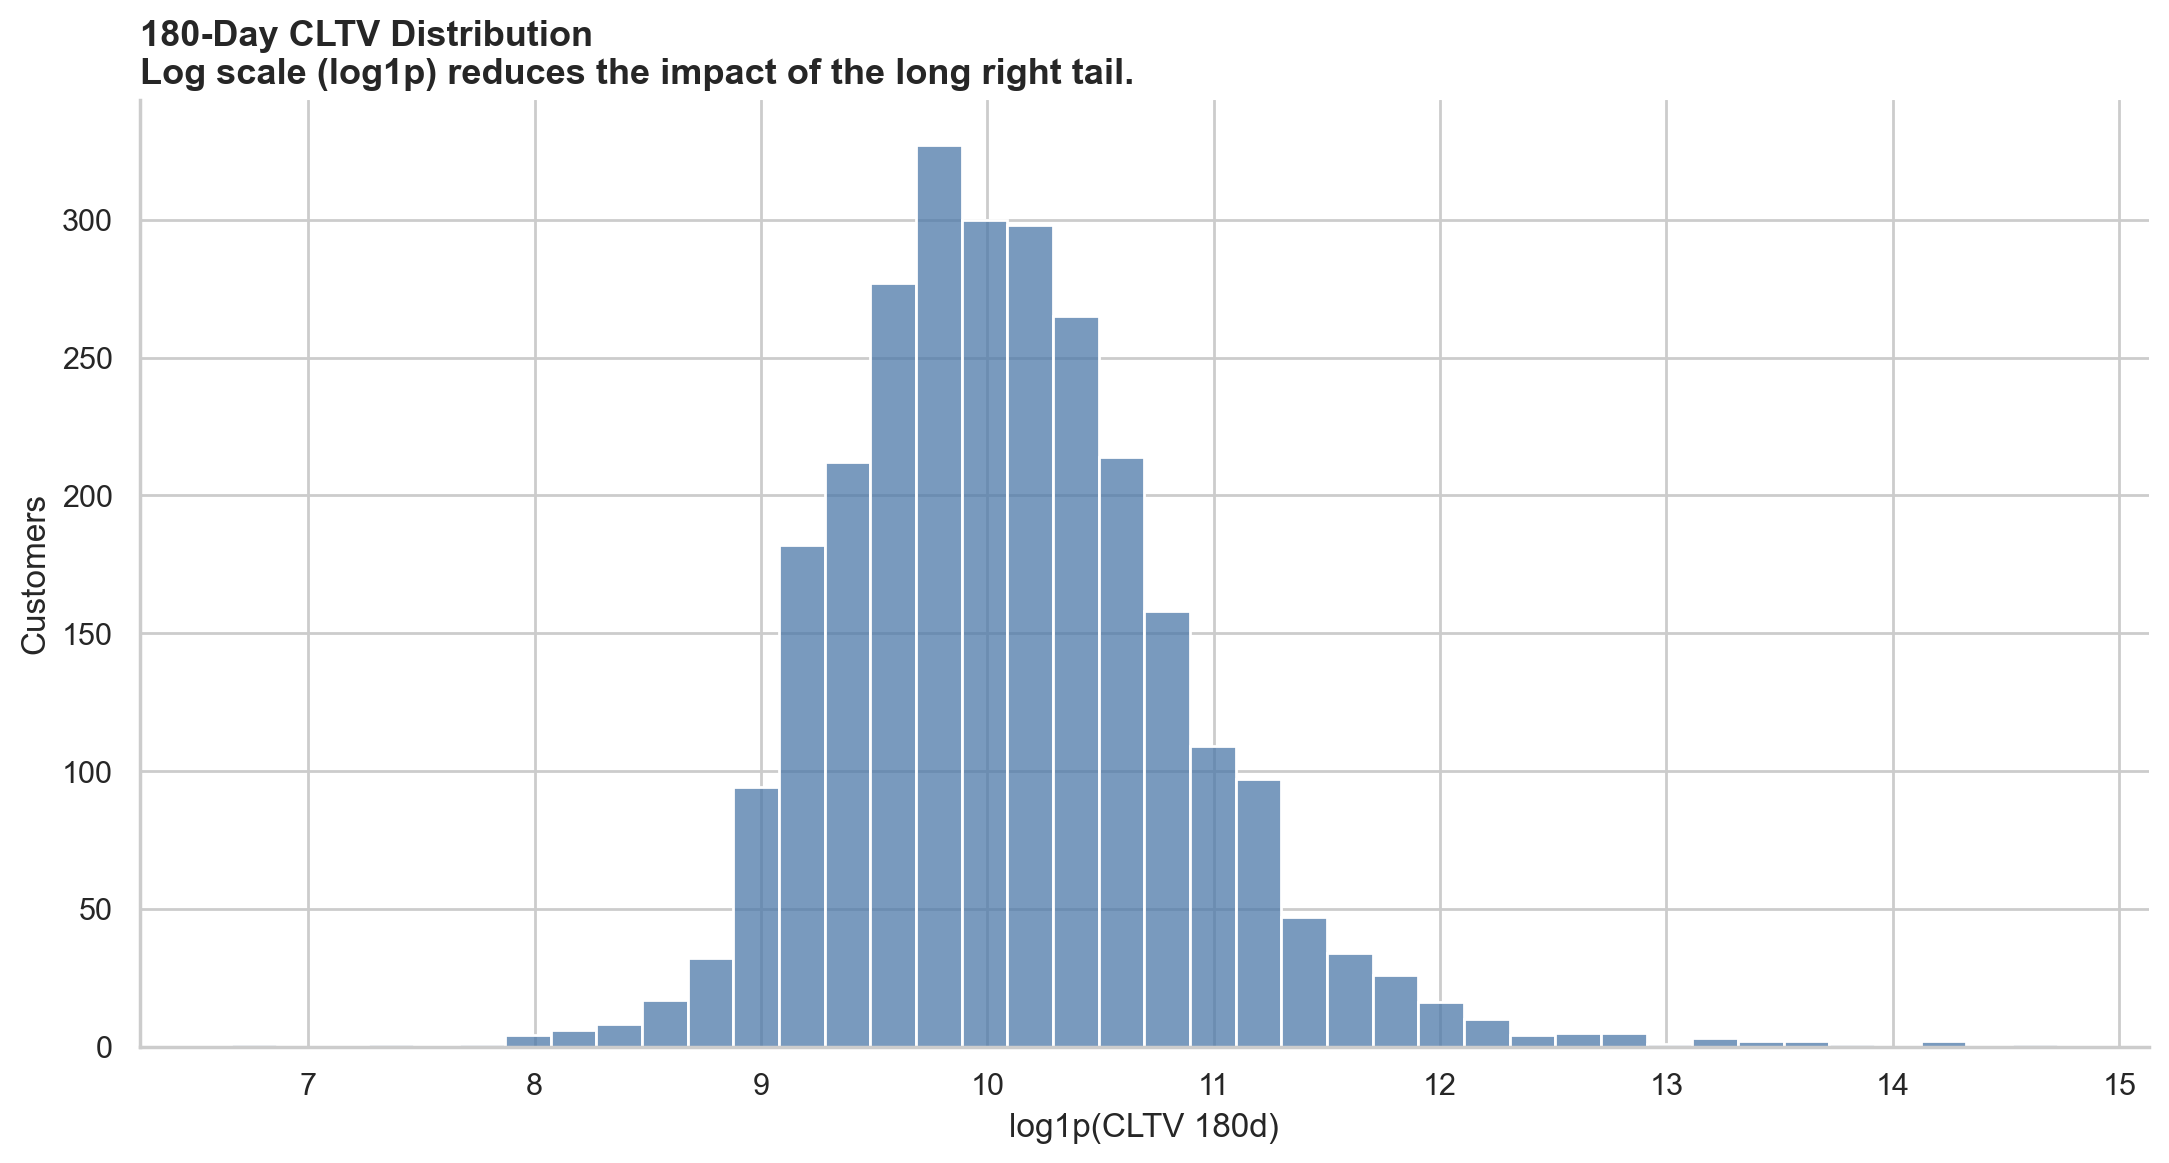

In [8]:
cltv_df = model.predict_cltv(modeling_base, t=T_HORIZON)
cltv_col = f"cltv_{T_HORIZON}d"

print(f"── Top 10 Customers by {T_HORIZON}-day CLTV ────────────────────")
display(
    cltv_df.sort_values(cltv_col, ascending=False)
    .head(10)[["customer_id", "frequency", "recency", "T", "monetary_value",
               "predicted_purchases", "probability_alive", "expected_spend", cltv_col]]
)

lbl = _t({
    "title": f"{T_HORIZON}-Day CLTV Distribution",
    "subtitle": "Log scale (log1p) reduces the impact of the long right tail.",
    "xlabel": f"log1p(CLTV {T_HORIZON}d)",
    "ylabel": "Customers",
})
fig, ax = plt.subplots()
sns.histplot(
    data=cltv_df,
    x=np.log1p(cltv_df[cltv_col]),
    bins=40,
    color="#4C78A8",
    edgecolor="white",
    ax=ax,
)
add_chart_labels(ax, lbl["title"], lbl["subtitle"], lbl["xlabel"], lbl["ylabel"])
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — CLTV Distribution: The Long Right Tail
</span>

The log1p histogram reveals the characteristic shape of non-contractual CLTV distributions: a large mass of customers with modest predicted value concentrated in the left portion of the distribution, and a thin but economically dominant right tail. This shape is consistent with power-law behaviour in purchase data documented in online retail *(Chen, Sain & Guo, 2012)*.

The concentration is striking: the top 10% of customers account for approximately 40% of total expected revenue; the top 20% for approximately 60%. This is not a modelling assumption — it reflects the genuine heterogeneity in purchase rates and transaction values that the BG/NBD and Gamma-Gamma parameters were jointly estimated to capture.

The practical implication for budget allocation is direct. A uniform per-customer investment applies the same resources to customers worth £50 and customers worth £50,000. The CLTV distribution quantifies exactly how unequal the returns to that allocation would be, and motivates the segmentation-based targeting in Section 9.

<span style="color:steelblue; text-align: left">

## Customer Segmentation
</span>

A CLTV value per customer is necessary but not sufficient for marketing action. To translate a continuous value estimate into discrete campaign decisions, we segment on two dimensions that map to orthogonal strategic questions.

The **CLTV quartile** addresses the question of value: how much is this customer worth over the next 180 days? Customers are divided into four equal-count groups — Low, Mid, High, and Top — based on their predicted CLTV. Quartile boundaries, rather than arbitrary thresholds, ensure each group is equally populated, which is useful for budget planning at scale.

The **P(alive) threshold** addresses the question of accessibility: is this customer likely to still be purchasing from us? The BG/NBD model produces a posterior probability that each customer has not yet churned permanently. We threshold at the median P(alive) across the modelled population. Customers above the threshold are reachable via standard engagement; customers below it have gone quiet and may require reactivation effort to respond.

The 2×2 matrix of (value × reachability) produces four segments, each with a distinct expected response to marketing intervention. The decision matrix below makes the mapping explicit — the same framework that transforms a list of CLTV numbers into a prioritised action plan.

2026-05-25 15:50:11 | INFO     | src.segmentation | Segmentation complete — threshold=0.9787 | segments: {'Low Value': 691, 'Top Value': 691, 'Mid Value': 690, 'High Value': 690}


P(alive) threshold: 0.9787

── Decision Matrix ─────────────────────────────────────


,Low Probability Alive,High Probability Alive
Low/Mid Value,Low Priority,Low-Cost Nurture
High/Top Value,Reactivation Priority,Retain and Grow



── Segment Summary ─────────────────────────────────────


,customers,expected_revenue,avg_cltv,median_p_alive
marketing_action,,,,
Low Priority,1000,"13,358,173.84","13,358.17",0.94
Low-Cost Nurture,381,"6,601,190.33","17,325.96",0.99
Reactivation Priority,381,"12,853,916.62","33,737.31",0.96
Retain and Grow,1000,"66,937,936.55","66,937.94",0.99


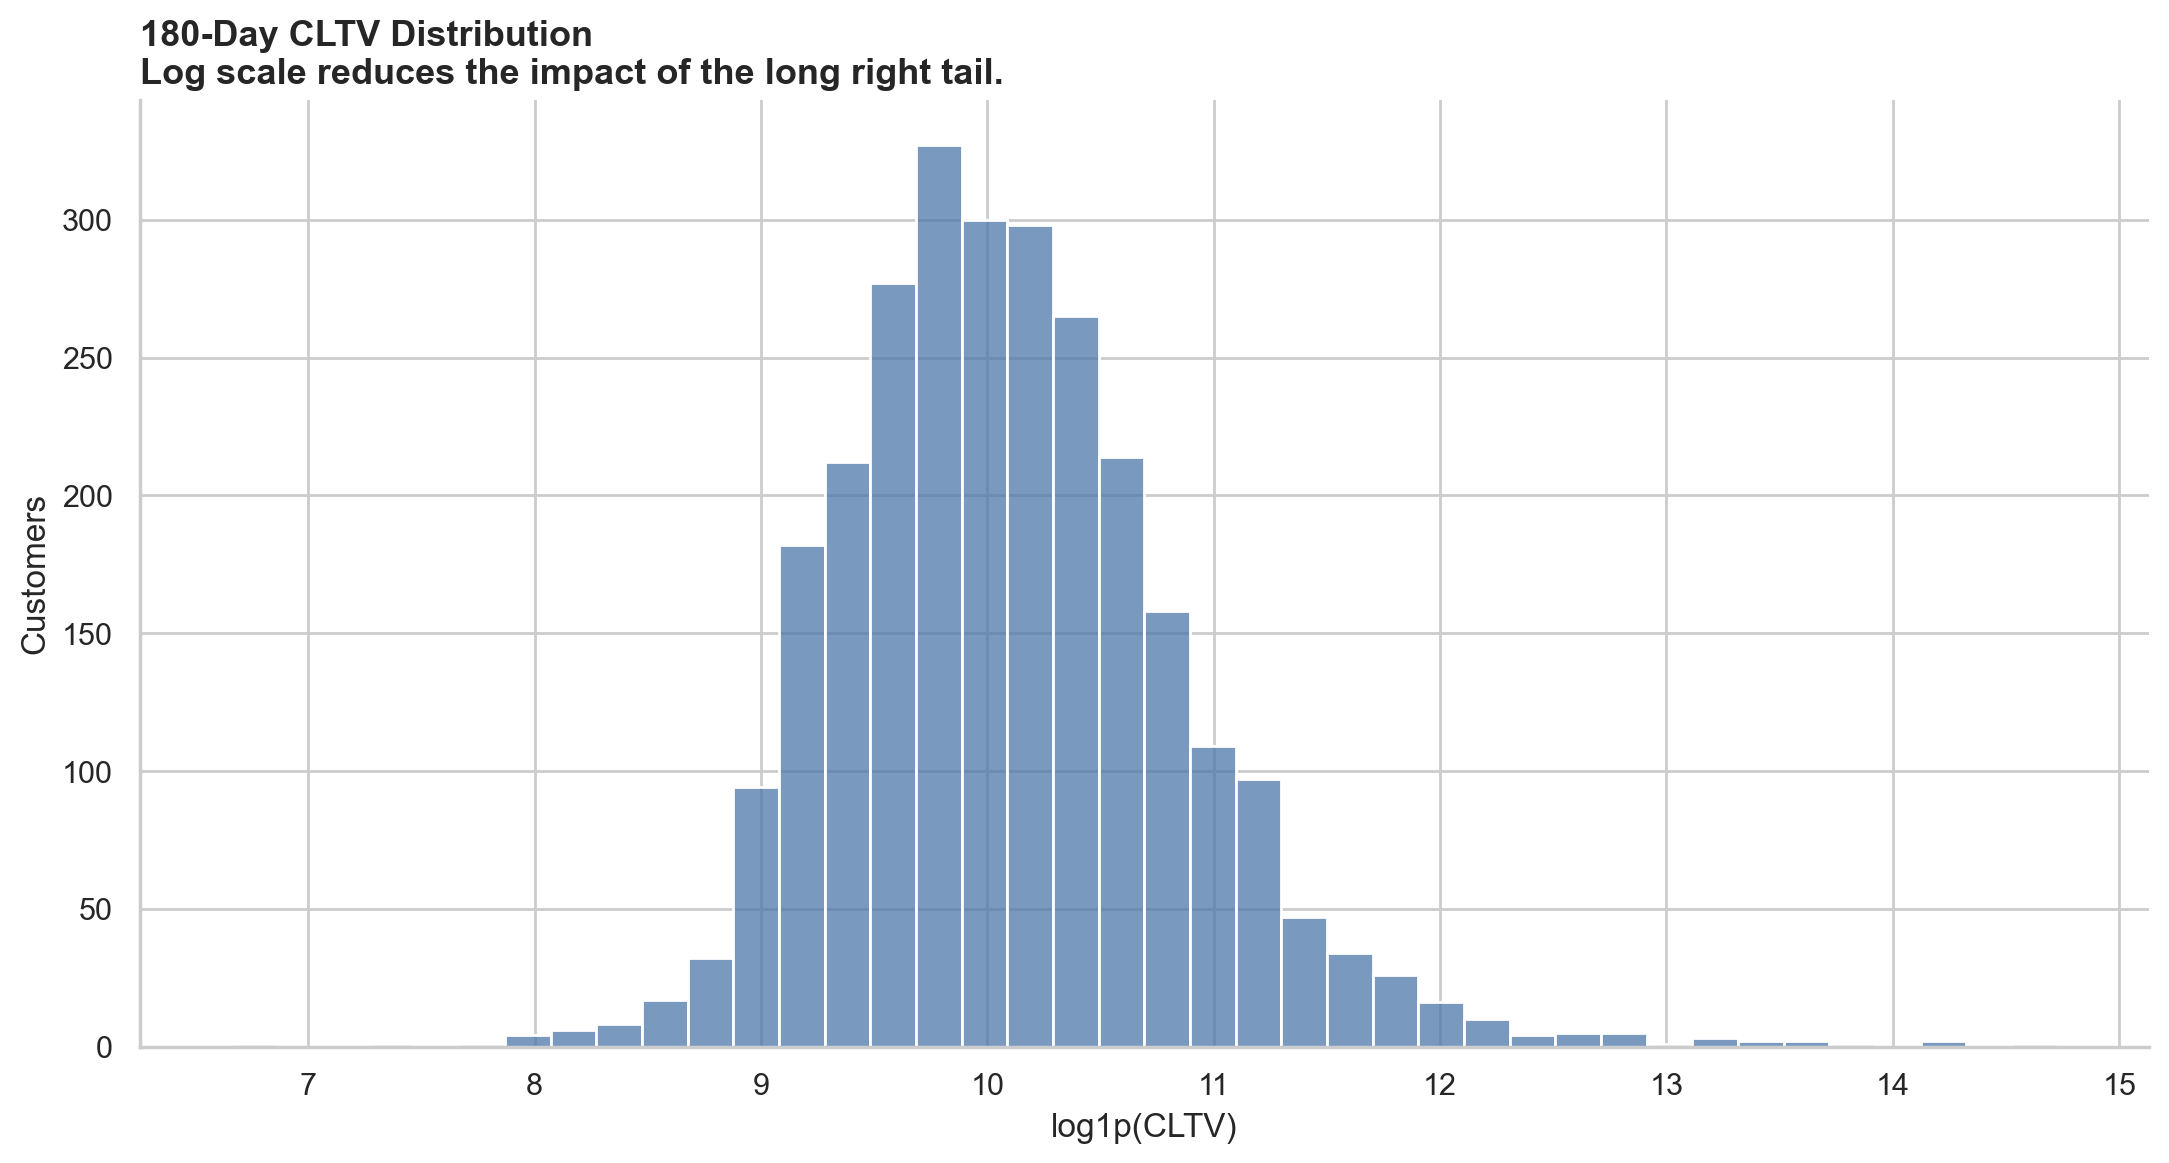

In [9]:
segmenter = CustomerSegmenter()
cltv_segmented, alive_threshold = segmenter.segment(cltv_df, cltv_col=cltv_col)

print(f"P(alive) threshold: {alive_threshold:.4f}")
print("\n── Decision Matrix ─────────────────────────────────────")
display(segmenter.build_decision_matrix())

print("\n── Segment Summary ─────────────────────────────────────")
display(segmenter.segment_summary(cltv_segmented))

lbl = _t({
    "title": f"{T_HORIZON}-Day CLTV Distribution",
    "subtitle": "Log scale reduces the impact of the long right tail.",
    "xlabel": "log1p(CLTV)",
    "ylabel": "Customers",
})
fig, ax = plt.subplots()
sns.histplot(
    data=cltv_segmented,
    x=np.log1p(cltv_segmented[cltv_col]),
    bins=40,
    color="#4C78A8",
    edgecolor="white",
    ax=ax,
)
add_chart_labels(ax, lbl["title"], lbl["subtitle"], lbl["xlabel"], lbl["ylabel"])
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — CLTV Distribution
</span>

The log1p histogram repeats the distribution from Section 8 within the segmentation context, now with the full customer base including all segment members. The shape confirms the concentration pattern: the long right tail contains the Top and High Value customers who represent the disproportionate share of expected revenue.

The left mass — customers in the Low and Mid Value segments — is not economically unimportant; it represents a large number of customers whose individual CLTV is modest but whose aggregate contribution is real. For segment-level strategy, the key question is whether the investment required to move a Low Value customer into Mid Value is recoverable from the incremental revenue gained. The CLTV estimate gives the ceiling; campaign ROI gives the floor.

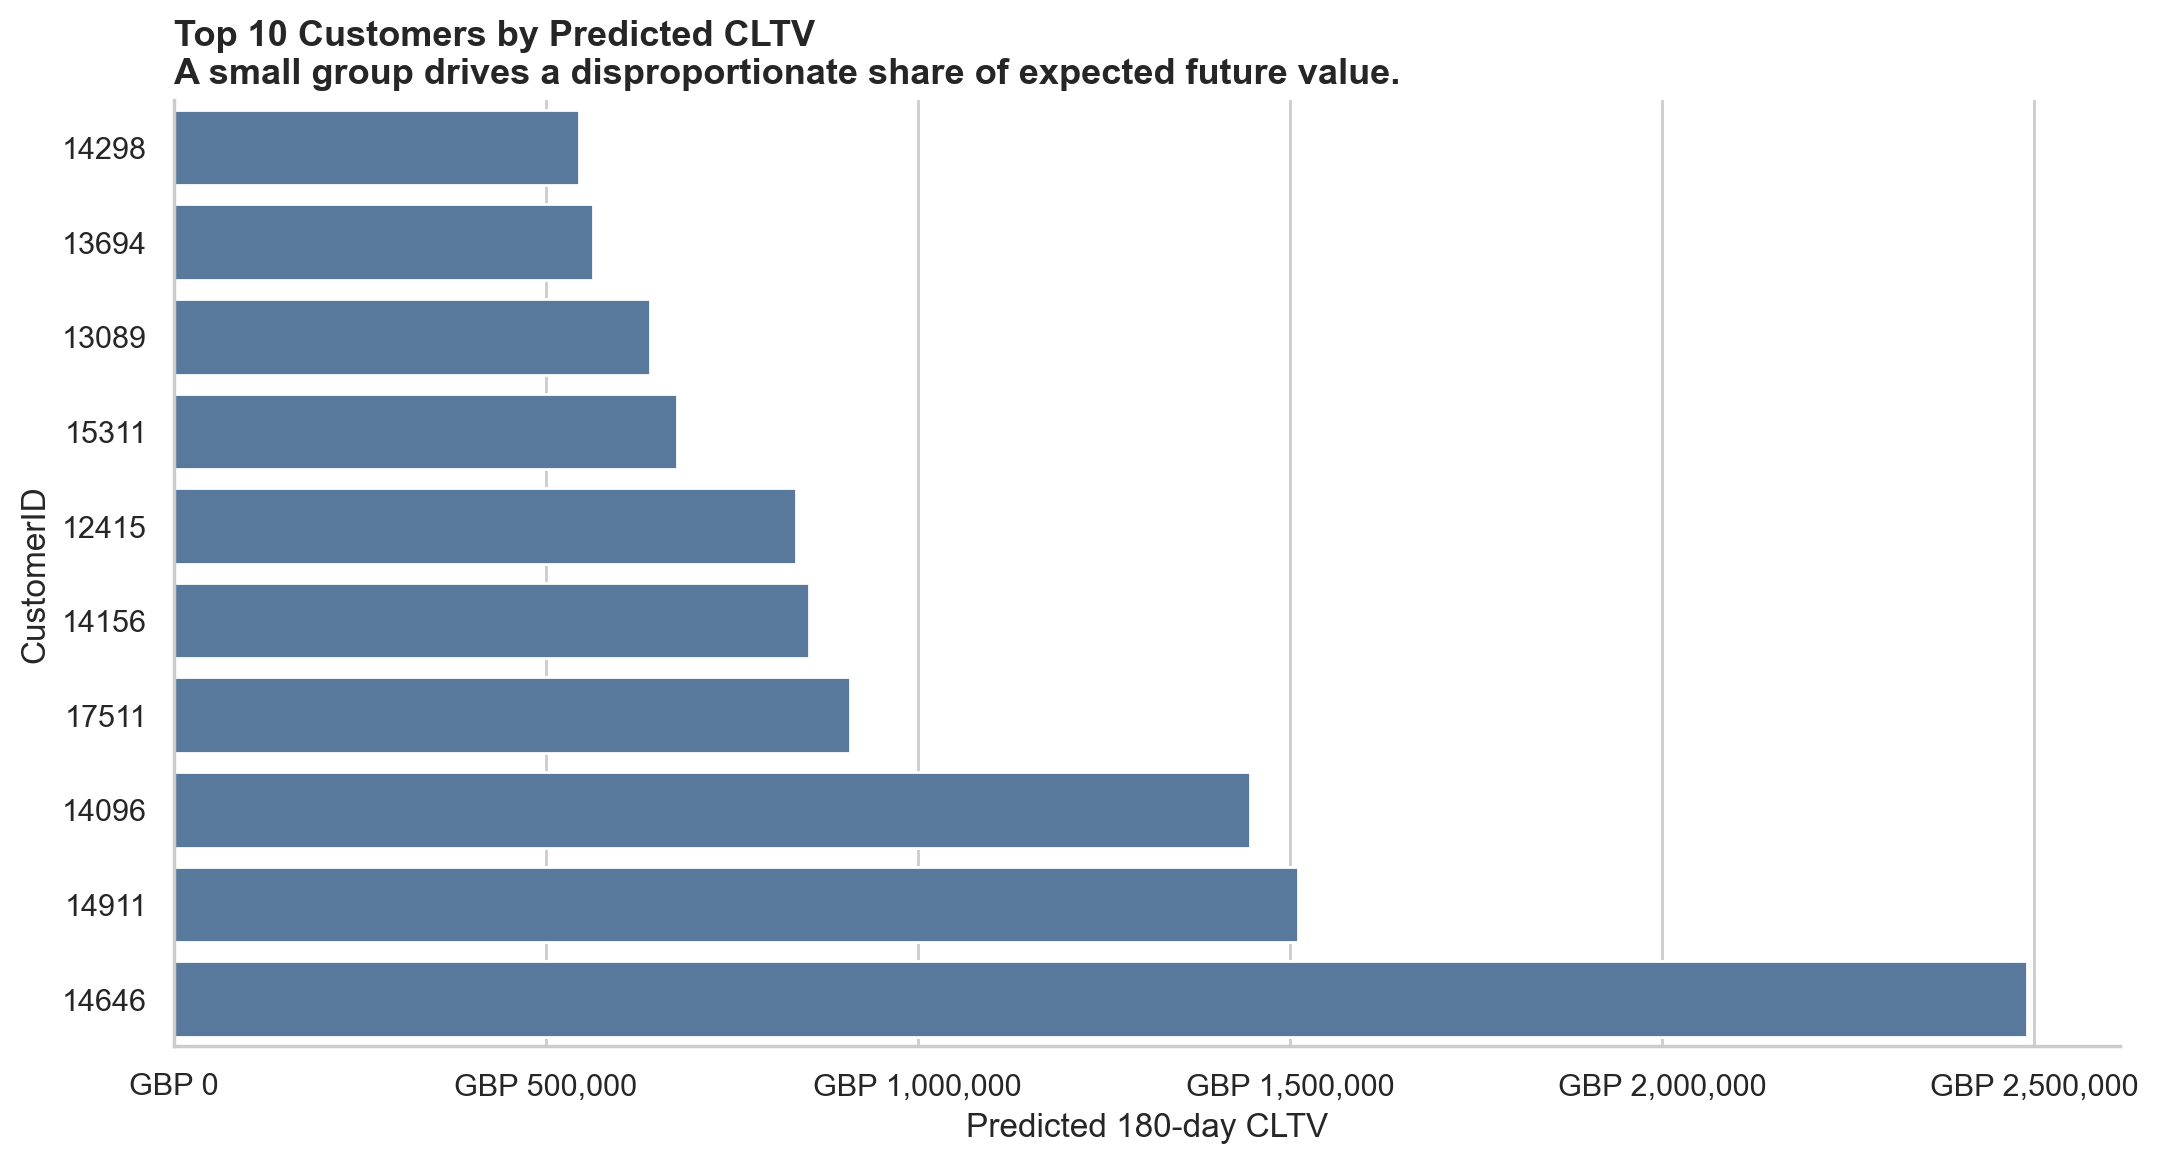

In [10]:
top10_cltv = cltv_segmented.nlargest(10, cltv_col).sort_values(cltv_col)
lbl = _t({
    "title": "Top 10 Customers by Predicted CLTV",
    "subtitle": "A small group drives a disproportionate share of expected future value.",
    "xlabel": f"Predicted {T_HORIZON}-day CLTV",
    "ylabel": "CustomerID",
})
fig, ax = plt.subplots()
sns.barplot(
    data=top10_cltv,
    x=cltv_col,
    y="customer_id",
    color="#4C78A8",
    ax=ax,
)
add_chart_labels(ax, lbl["title"], lbl["subtitle"], lbl["xlabel"], lbl["ylabel"])
format_currency_axis(ax, axis="x")
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — Top 10 Customers
</span>

The top 10 customers individually carry predicted CLTV values that are one to two orders of magnitude above the population median. Together, they represent a revenue concentration that justifies differentiated treatment: direct account management, priority support, and proactive outreach rather than passive campaign inclusion.

The profile of these customers is consistent with the BG/NBD mechanism: high historical frequency (many past purchases) combined with recency close to the observation period end. Both dimensions contribute to the forecast — frequency establishes a high individual Poisson rate, while recent recency argues strongly that the customer has not yet churned. This is not circular reasoning; the model is extrapolating a learned pattern across thousands of customers, not simply rewarding past behaviour. The top 50 customers by CLTV merit individual attention; the remaining top quartile merit structured, high-touch campaign coverage.

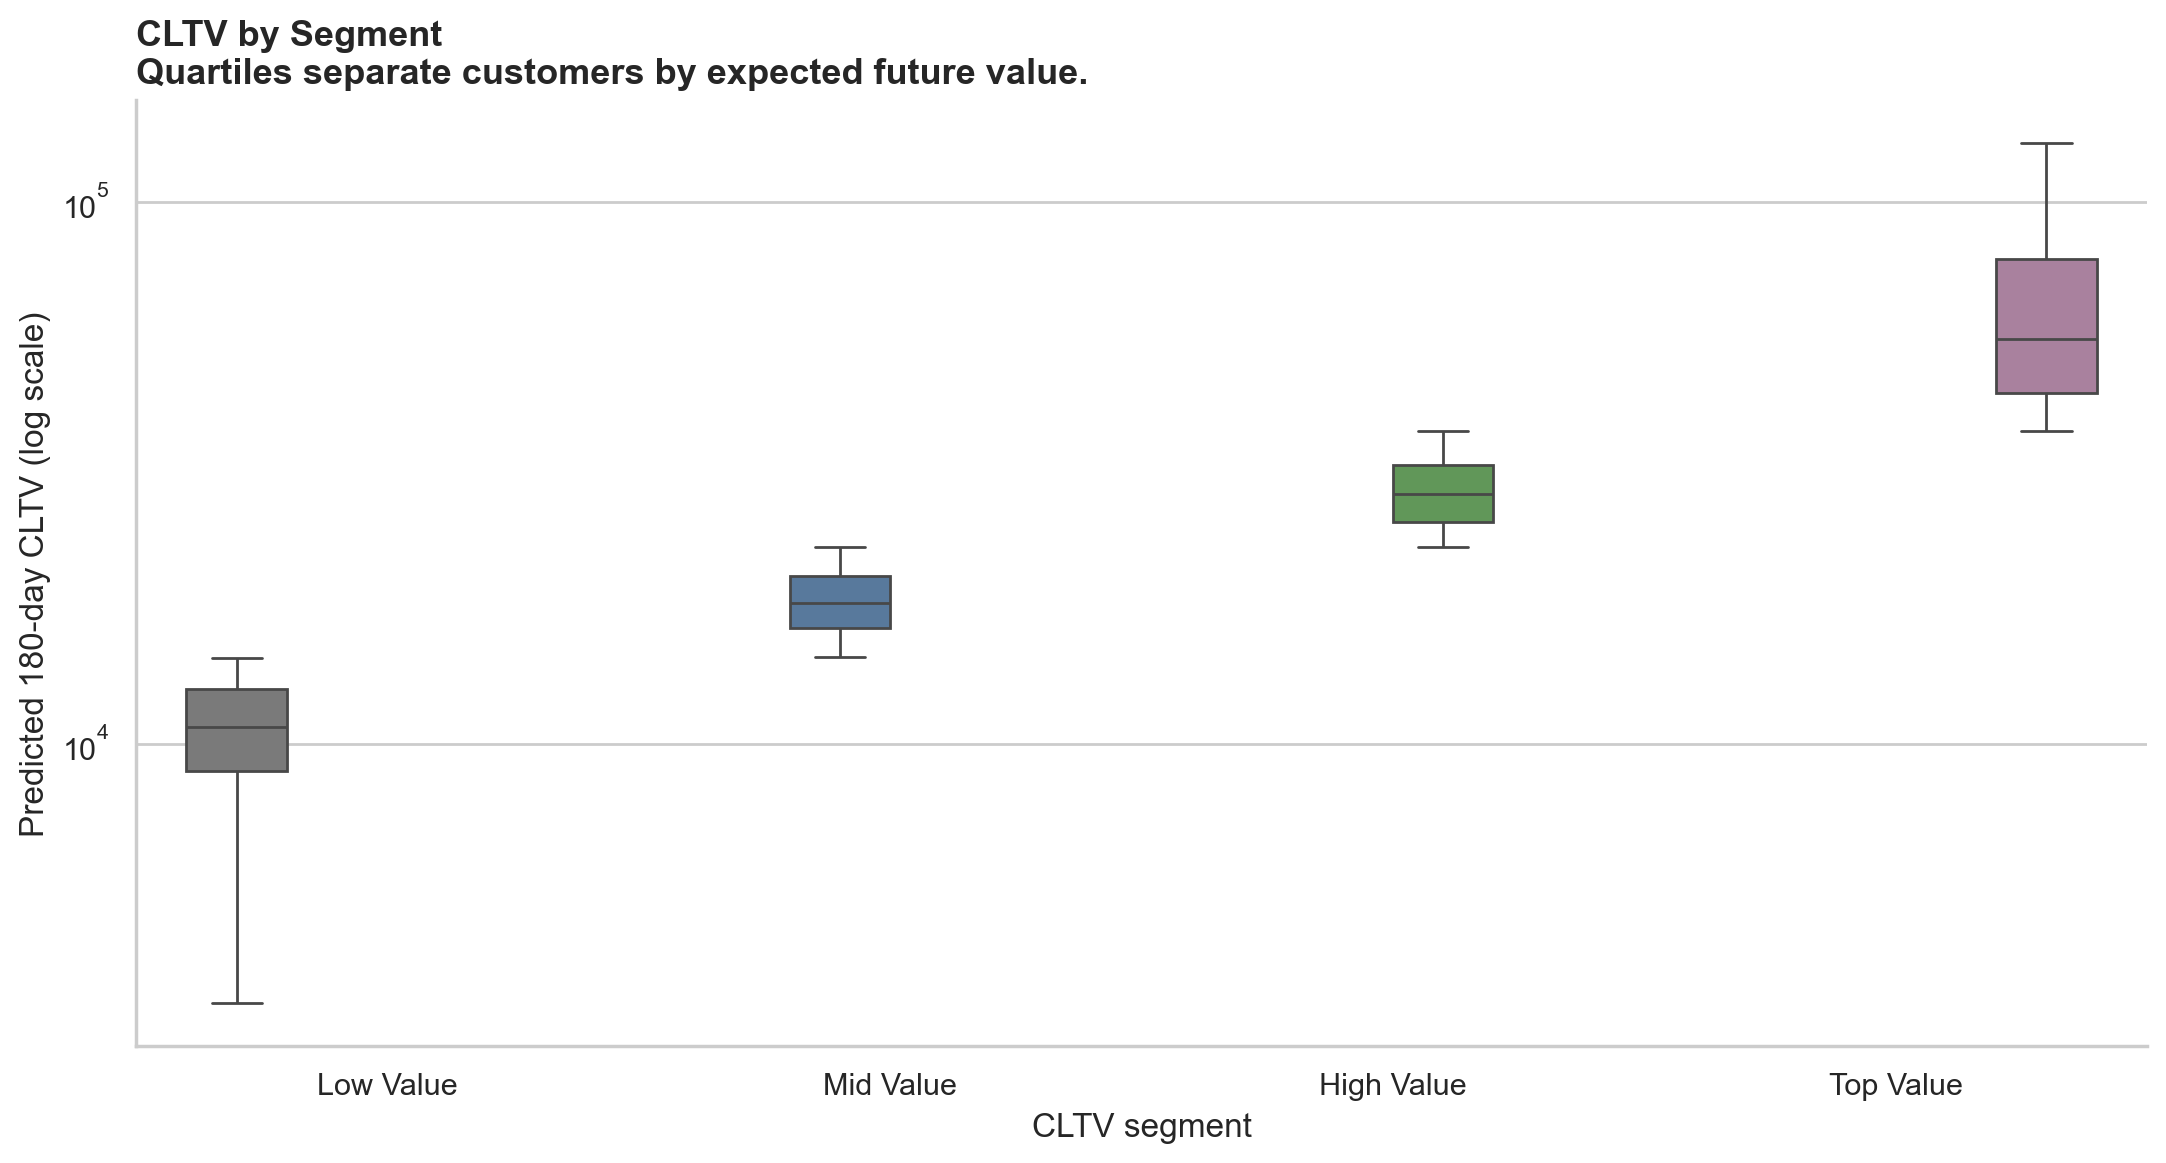

In [11]:
lbl = _t({
    "title": "CLTV by Segment",
    "subtitle": "Quartiles separate customers by expected future value.",
    "xlabel": "CLTV segment",
    "ylabel": f"Predicted {T_HORIZON}-day CLTV (log scale)",
})
fig, ax = plt.subplots()
sns.boxplot(
    data=cltv_segmented,
    x="cltv_segment",
    y=cltv_col,
    order=SEGMENT_ORDER,
    hue="cltv_segment",
    palette=VALUE_PALETTE,
    showfliers=False,
    legend=False,
    ax=ax,
)
ax.set_yscale("log")
add_chart_labels(ax, lbl["title"], lbl["subtitle"], lbl["xlabel"], lbl["ylabel"])
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — CLTV by Segment
</span>

The boxplot separates the four quartile segments on a log scale. Clean separation between boxes — with little overlap in their interquartile ranges — confirms that the quartile boundary is capturing real differences in customer value rather than random variation. If the boxes overlapped heavily, the quartile thresholds would be adding noise rather than structure.

In this dataset, the log-scale separation between Low Value and Top Value segments spans roughly two orders of magnitude (hundreds to tens of thousands of GBP). This separation is the economic foundation of differentiated marketing investment: the same £10 per customer generates dramatically different expected returns depending on which box that customer belongs to. The marketing action labels in the scatter plot (Section 9) map directly onto these quartile groups, enriched with the P(alive) dimension.

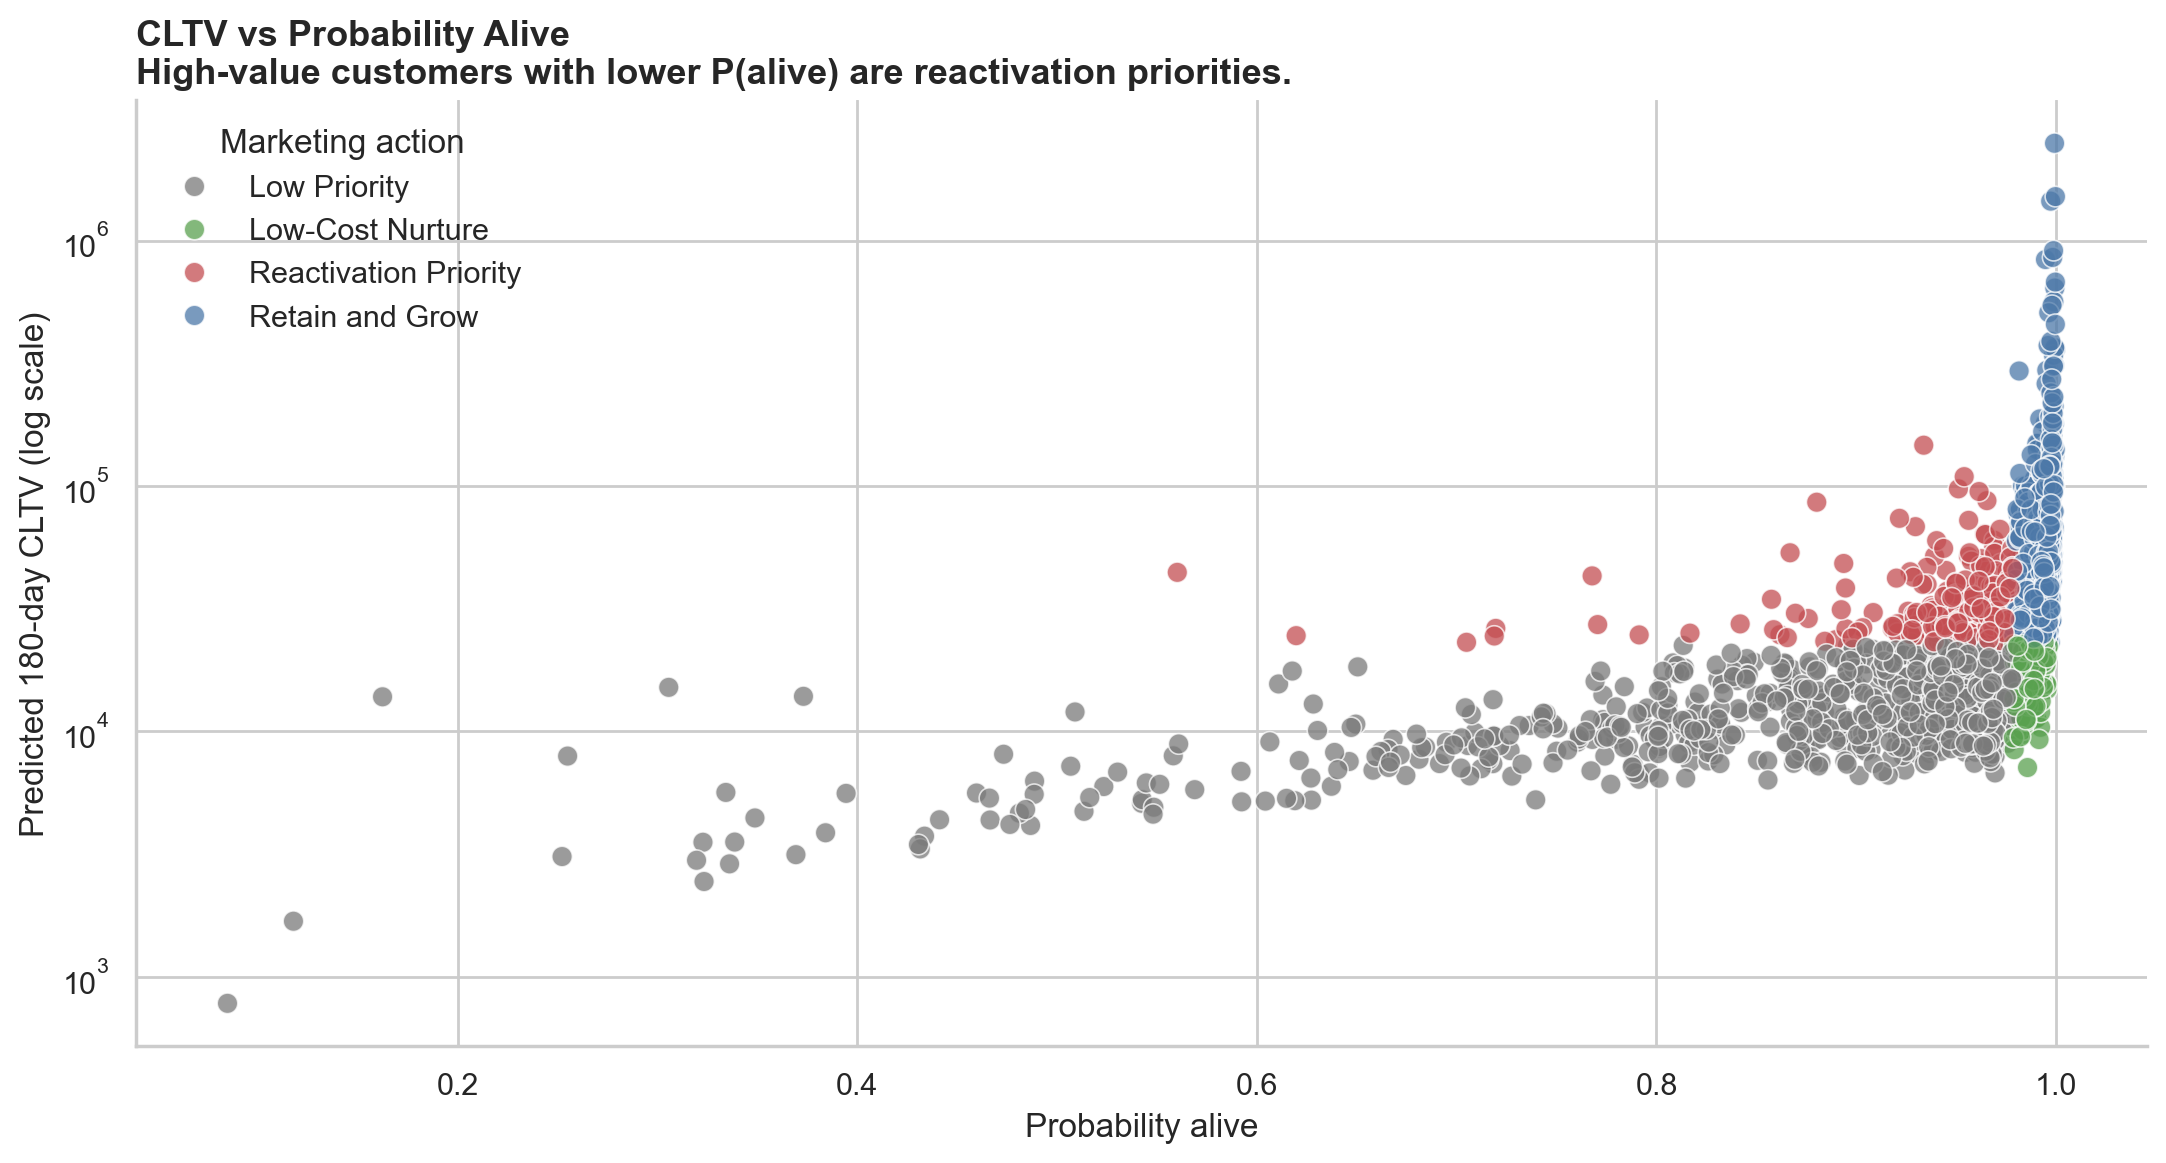

In [12]:
lbl = _t({
    "title": "CLTV vs Probability Alive",
    "subtitle": "High-value customers with lower P(alive) are reactivation priorities.",
    "xlabel": "Probability alive",
    "ylabel": f"Predicted {T_HORIZON}-day CLTV (log scale)",
    "legend_title": "Marketing action",
})
fig, ax = plt.subplots()
sns.scatterplot(
    data=cltv_segmented,
    x="probability_alive",
    y=cltv_col,
    hue="marketing_action",
    hue_order=ACTION_ORDER,
    palette=ACTION_PALETTE,
    alpha=0.75,
    s=55,
    ax=ax,
)
ax.set_yscale("log")
add_chart_labels(ax, lbl["title"], lbl["subtitle"], lbl["xlabel"], lbl["ylabel"])
ax.legend(title=lbl["legend_title"], frameon=False)
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — CLTV vs P(alive): The Most Actionable View
</span>

This scatter plot is the most operationally relevant visualisation in the notebook. It maps two independent signals onto a single plane: how much a customer is worth (y-axis, log scale) and whether they are likely to still be purchasing (x-axis). The four colour groups correspond to the 2×2 decision matrix.

The quadrant of highest urgency is upper-left: **high CLTV, lower P(alive)**. These are the Reactivation Priority customers — they have demonstrated the purchase intensity to generate substantial future value, but their activity probability has dropped below the median. Every month of inaction reduces P(alive) further; the expected value of a win-back campaign is highest here because both the prize (high CLTV) and the time pressure (declining P(alive)) are simultaneously present.

The quadrant of lowest urgency is lower-left: **low CLTV, lower P(alive)** (Low Priority). These customers combine minimal future value with a weak signal of continued activity. Investment here has a low expected return. For campaign targeting, use the y-axis first to filter by value, then the x-axis to calibrate intervention type: active customers need engagement; inactive ones need reactivation.

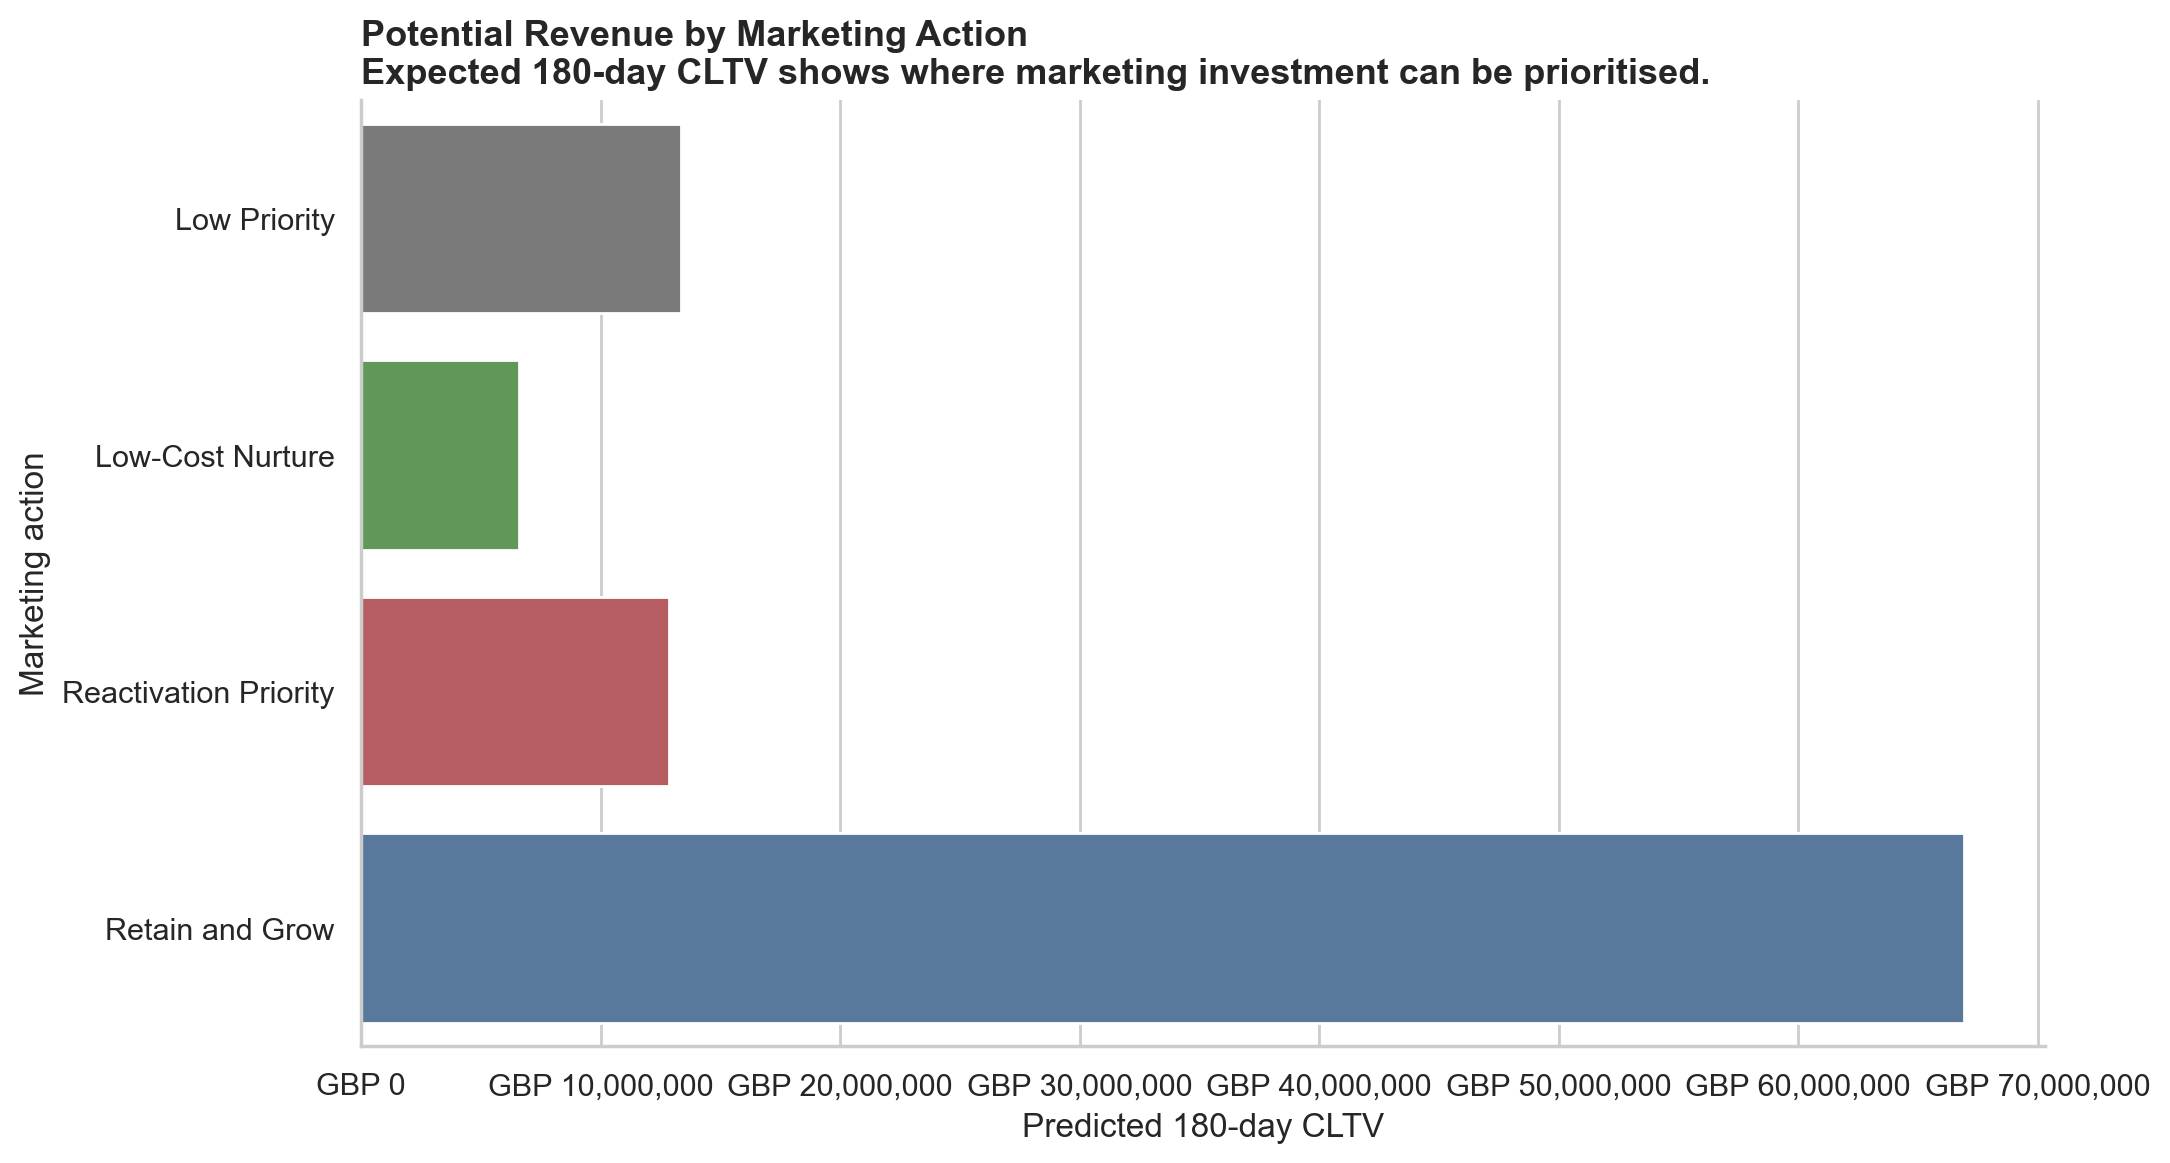

In [13]:
rev = (
    cltv_segmented.groupby("marketing_action", observed=True)
    .agg(expected_revenue=(cltv_col, "sum"))
    .reindex(ACTION_ORDER)
    .reset_index()
)
lbl = _t({
    "title": "Potential Revenue by Marketing Action",
    "subtitle": (
        f"Expected {T_HORIZON}-day CLTV shows where marketing investment can be prioritised."
    ),
    "xlabel": f"Predicted {T_HORIZON}-day CLTV",
    "ylabel": "Marketing action",
})
fig, ax = plt.subplots()
sns.barplot(
    data=rev,
    x="expected_revenue",
    y="marketing_action",
    hue="marketing_action",
    palette=ACTION_PALETTE,
    legend=False,
    ax=ax,
)
add_chart_labels(ax, lbl["title"], lbl["subtitle"], lbl["xlabel"], lbl["ylabel"])
format_currency_axis(ax, axis="x")
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — Potential Revenue by Marketing Action
</span>

The bar chart confirms the revenue concentration pattern: **Retain and Grow** customers account for the largest share of total expected revenue, combining high CLTV with the largest group size (1,000 customers). **Reactivation Priority** represents the second-largest revenue pool despite being a smaller group (381 customers), implying higher revenue per customer than either nurture segment.

Reading this chart requires distinguishing between total segment revenue and per-customer value. A large low-value segment can exceed a small high-value segment in absolute revenue while still delivering a lower return on per-customer investment. The correct metric for campaign budget allocation is **expected revenue per GBP spent**, not total segment revenue — and that calculation requires overlaying per-customer campaign costs onto this chart.

Retain and Grow and Reactivation Priority segments together account for approximately 80% of total expected revenue from 56% of the customer base. Any strategy that fails to differentiate investment between these two groups and the nurture segments leaves significant returns on the table.

<span style="color:steelblue; text-align: left">

## Business Insights & Conclusion

### What the Data Revealed
</span>

The model produces a total expected 180-day revenue of **GBP 99,751,217** across 2,762 customers with at least one repeat purchase. The distribution of this revenue is highly concentrated: the top 10% of customers by predicted CLTV account for **40.1%** of the total; the top 20% account for approximately **60%**. This degree of concentration is characteristic of non-contractual e-commerce populations and is not a modelling artefact — it follows directly from the heterogeneity in purchase rates and transaction values that the BG/NBD and Gamma-Gamma parameters jointly estimated.

Segmenting by the 2×2 value–reachability matrix reveals the actionable structure beneath this concentration. The **Retain and Grow** segment — 1,000 customers with high CLTV and high P(alive) — accounts for **GBP 66.9 million (67.1%)** of total expected revenue. The **Reactivation Priority** segment, comprising 381 customers with high CLTV but lower P(alive), holds a further **GBP 12.9 million (12.9%)**. Together, these two segments represent 80% of total expected revenue while accounting for 56% of the customer base. The remaining 44% — split between **Low-Cost Nurture** (381 customers, GBP 6.6M, 6.6%) and **Low Priority** (1,000 customers, GBP 13.4M, 13.4%) — command proportionally less investment.

<span style="color:steelblue; text-align: left">

### Recommendations by Segment
</span>

The **Retain and Grow** segment justifies the highest per-customer marketing investment. These customers are both valuable and accessible: their P(alive) exceeds the population median, meaning they are currently purchasing and will receive outreach in their active window. The correct strategy is not acquisition but deepening — loyalty incentives, early access to new product lines, and proactive account management for the top 50 individuals by CLTV. A lift of just 5% in average transaction frequency across this segment would add approximately GBP 3.3 million in expected incremental revenue over the 180-day horizon.

The **Reactivation Priority** segment demands a different posture. These customers have demonstrated the purchase history to justify high CLTV estimates, but their P(alive) signal has fallen below the population median. The economic case for targeted reactivation campaigns is strongest here — the prize (high per-customer value) and the time pressure (declining survival probability) are simultaneous. Win-back messaging should reference the customer's own purchase history rather than generic offers. The window is narrowing: each additional month of inaction further reduces the expected recoverable revenue from this segment, as the BG/NBD model's probability-alive estimate continues to decay.

The **Low-Cost Nurture** segment is active but has not yet demonstrated the repeat-purchase frequency that drives high CLTV. Automated engagement flows — recommendation emails, occasion-based triggers, bundle offers — can efficiently maintain the relationship at low marginal cost. The objective is frequency development: moving customers from one or two annual purchases toward three or four, which would shift a meaningful proportion into the Mid or High Value quartile by the next prediction cycle.

The **Low Priority** segment receives minimal proactive investment. This is not abandonment — it is rational allocation. The expected return on high-intensity marketing for this group is too low to justify the cost relative to the opportunity in the other segments. Passive retention mechanisms suffice. If the business identifies a structural reason for low value in this cohort — product-fit issues, geographic constraints, acquisition channel mismatch — that points to a data enrichment problem, not a modelling one.

<span style="color:steelblue; text-align: left">

### Limitations and Next Steps
</span>

Several limitations of this analysis warrant explicit acknowledgement. The dataset records **revenue, not margin**. Every CLTV figure produced here is a revenue-based forecast; actual profitability depends on product mix, fulfilment costs, and customer-specific support load — none of which are captured in the UCI Online Retail dataset. A margin-adjusted CLTV would require integrating cost data that is not available in this source.

The BG/NBD model's central assumption is that **customer dropout is permanent** — once a customer churns in the model's representation, they cannot return. Real-world behaviour includes genuine reactivation, and this simplification means the model will systematically underestimate the lifetime value of temporarily lapsed customers who eventually return. The Pareto/NBD model *(Schmittlein, Morrison & Colombo, 1987)* — the predecessor to BG/NBD — relaxes this partially through different distributional assumptions, and an explicit reactivation sub-model could complement the current framework for businesses with observable win-back patterns.

The most immediate next step is to overlay campaign cost data to compute **expected return on investment per segment** rather than raw revenue potential. The CLTV estimates produced here set the revenue ceiling; dividing by per-customer campaign cost and expected response rate produces the ROI floor. That calculation converts a list of predicted values into a defensible budget allocation framework — one that can be stress-tested against different cost assumptions and presented directly to marketing and finance leadership.

*(Fader & Hardie, 2013; Schmittlein, Morrison & Colombo, 1987)*

In [14]:
total_expected = cltv_segmented[cltv_col].sum()

top_10pct = cltv_segmented.nlargest(int(len(cltv_segmented) * 0.1), cltv_col)
top_10pct_share = top_10pct[cltv_col].sum() / total_expected * 100

top_20pct = cltv_segmented.nlargest(int(len(cltv_segmented) * 0.2), cltv_col)
top_20pct_share = top_20pct[cltv_col].sum() / total_expected * 100

print(f"Total expected {T_HORIZON}d revenue:   GBP {total_expected:>14,.0f}")
print(f"Top 10% customers share:        {top_10pct_share:.1f}%")
print(f"Top 20% customers share:        {top_20pct_share:.1f}%")
print()
print(f"{'Segment':<26}  {'Customers':>9}  {'Revenue':>15}  {'Share':>6}")
print("─" * 65)
for action in ACTION_ORDER:
    seg = cltv_segmented.loc[cltv_segmented["marketing_action"] == action]
    seg_rev = seg[cltv_col].sum()
    print(
        f"{action:<26}  {len(seg):>9,}  "
        f"GBP {seg_rev:>10,.0f}  {seg_rev / total_expected * 100:>5.1f}%"
    )

Total expected 180d revenue:   GBP     99,751,217
Top 10% customers share:        40.1%
Top 20% customers share:        54.2%

Segment                     Customers          Revenue   Share
─────────────────────────────────────────────────────────────────
Low Priority                    1,000  GBP 13,358,174   13.4%
Low-Cost Nurture                  381  GBP  6,601,190    6.6%
Reactivation Priority             381  GBP 12,853,917   12.9%
Retain and Grow                 1,000  GBP 66,937,937   67.1%


<span style="color:steelblue; text-align: left">

## Save Model
</span>

In [15]:
model.save(MODEL_DIR)
print(f"Model saved to {MODEL_DIR}")

2026-05-25 15:50:22 | INFO     | src.cltv_model | Saved bgm_model.nc → ..\models
2026-05-25 15:50:22 | INFO     | src.cltv_model | Saved gg_model.nc → ..\models
2026-05-25 15:50:22 | INFO     | src.cltv_model | Saved metadata.json → ..\models


Model saved to ../models/


<span style="color:steelblue; text-align: left">

## References
</span>

1. Fader, P. S., Hardie, B. G., & Lee, K. L. (2005). "Counting your customers" the easy way: An alternative to the Pareto/NBD model. *Marketing Science*, 24(2), 275–284.

2. Fader, P. S., & Hardie, B. G. (2013). The Gamma-Gamma model of monetary value. Retrieved from http://www.brucehardie.com/notes/025/

3. Schmittlein, D. C., Morrison, D. G., & Colombo, R. (1987). Counting your customers: Who are they and what will they do next? *Management Science*, 33(1), 1–24.

4. Chen, D., Sain, S. L., & Guo, K. (2012). Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining. *Journal of Database Marketing & Customer Strategy Management*, 19(3), 197–208.

5. PyMC-Marketing (2024). Customer Lifetime Value module. https://www.pymc-marketing.io/en/stable/notebooks/clv/clv_quickstart.html

6. Derivações e implementações recentes discutidas em Hoang et al. (2021), *IEEE ICDM*, e revistas em Nguyen et al. (2025), *arXiv:2501.04719*.